In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler,RobustScaler
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from collections import defaultdict,deque
import pickle

In [43]:
stages_url="https://raw.githubusercontent.com/thomascamminady/LeTourDataSet/master/data/men/TDF_Stages_History.csv"
riders_url="https://raw.githubusercontent.com/thomascamminady/LeTourDataSet/master/data/men/TDF_Riders_History.csv"
stages=pd.read_csv(stages_url)
riders=pd.read_csv(riders_url)

In [44]:
stages.tail()

,Year,TotalTDFDistance,Stages,Start,End,Winner of stage,Yellow Jersey,Green jersey,Polka-dot jersey,White jersey,Leader
2408,2025,3323,17.0,Bollène,Valence,Jonathan Milan (Lidl-Trek),Tadej Pogacar,Jonathan Milan,Lenny Martinez,Florian Lipowitz,NaN
2409,2025,3323,18.0,Vif,Courchevel Col de la Loze,Ben Alexander O'Connor (Team Jayco Alula),Tadej Pogacar,Jonathan Milan,Jonas Vingegaard Hansen,Florian Lipowitz,NaN
2410,2025,3323,19.0,Albertville,La Plagne,Thymen Arensman (Ineos Grenadiers),Tadej Pogacar,Jonathan Milan,Jonas Vingegaard Hansen,Florian Lipowitz,NaN
2411,2025,3323,20.0,Nantua,Pontarlier,Kaden Groves (Alpecin-Deceuninck),Tadej Pogacar,Jonathan Milan,Jonas Vingegaard Hansen,Florian Lipowitz,NaN
2412,2025,3323,21.0,Mantes-la-Ville,Paris Champs-Élysées,Wout Van Aert (Team Visma | Lease A Bike),Tadej Pogacar,Jonathan Milan,Tadej Pogacar,Florian Lipowitz,NaN


In [45]:
riders[riders["Rider"]=="TADEJ POGACAR"]

,Rank,Rider,Rider No.,Team,Times,Gap,B,P,Year,Distance (km),Number of stages,ResultType,TotalSeconds,GapSeconds
9306,1,TADEJ POGACAR,131,UAE TEAM EMIRATES,87h 20' 05'',-,32',NaN,2020,3483,21,time,314405,0
9452,1,TADEJ POGACAR,1,UAE TEAM EMIRATES,82h 56' 36'',-,36',NaN,2021,3383,21,time,298596,0
9594,2,TADEJ POGACAR,1,UAE TEAM EMIRATES,79h 36' 03'',+ 00h 02' 43'',40',NaN,2022,3328,24,time,286563,163
9729,2,TADEJ POGACAR,11,UAE TEAM EMIRATES,82h 13' 11'',+ 00h 07' 29'',51',NaN,2023,3404,21,time,295991,449
9878,1,TADEJ POGACAR,11,UAE TEAM EMIRATES,83h 38' 56'',-,12',NaN,2024,3492,21,time,301136,0
10019,1,TADEJ POGACAR,1,UAE TEAM EMIRATES XRG,76h 00' 32'',-,52',NaN,2025,3323,21,time,273632,0


In [46]:
filtered_riders=riders[riders['ResultType']=='time']

## Feature preprocessing
1. Calculate rider's avg speed over the whole tour
2. Get Rider's recent 3 finishes(Rank) average
3. Get Rider's avg stage wins in the previous 3 years.
3.2 Use the rider's prev stage wins, and Rider's recent finishes to calculate his rating.

In [47]:
filtered_riders.tail()

,Rank,Rider,Rider No.,Team,Times,Gap,B,P,Year,Distance (km),Number of stages,ResultType,TotalSeconds,GapSeconds
10174,156,ROEL VAN SINTMAARTENSDIJK,47,INTERMARCHÉ - WANTY,81h 44' 43'',+ 05h 44' 11'',NaN,NaN,2025,3323,21,time,294283,20651
10175,157,FABIAN LIENHARD,115,TUDOR PRO CYCLING TEAM,81h 46' 32'',+ 05h 46' 00'',NaN,NaN,2025,3323,21,time,294392,20760
10176,158,JORDI MEEUS,73,RED BULL - BORA - HANSGROHE,81h 48' 57'',+ 05h 48' 25'',06',NaN,2025,3323,21,time,294537,20905
10177,159,EDWARD THEUNS,88,LIDL-TREK,81h 51' 57'',+ 05h 51' 25'',NaN,NaN,2025,3323,21,time,294717,21085
10178,160,SIMONE CONSONNI,82,LIDL-TREK,81h 52' 12'',+ 05h 51' 40'',NaN,NaN,2025,3323,21,time,294732,21100


In [48]:
stages.tail()

,Year,TotalTDFDistance,Stages,Start,End,Winner of stage,Yellow Jersey,Green jersey,Polka-dot jersey,White jersey,Leader
2408,2025,3323,17.0,Bollène,Valence,Jonathan Milan (Lidl-Trek),Tadej Pogacar,Jonathan Milan,Lenny Martinez,Florian Lipowitz,NaN
2409,2025,3323,18.0,Vif,Courchevel Col de la Loze,Ben Alexander O'Connor (Team Jayco Alula),Tadej Pogacar,Jonathan Milan,Jonas Vingegaard Hansen,Florian Lipowitz,NaN
2410,2025,3323,19.0,Albertville,La Plagne,Thymen Arensman (Ineos Grenadiers),Tadej Pogacar,Jonathan Milan,Jonas Vingegaard Hansen,Florian Lipowitz,NaN
2411,2025,3323,20.0,Nantua,Pontarlier,Kaden Groves (Alpecin-Deceuninck),Tadej Pogacar,Jonathan Milan,Jonas Vingegaard Hansen,Florian Lipowitz,NaN
2412,2025,3323,21.0,Mantes-la-Ville,Paris Champs-Élysées,Wout Van Aert (Team Visma | Lease A Bike),Tadej Pogacar,Jonathan Milan,Tadej Pogacar,Florian Lipowitz,NaN


In [49]:
# Count stages won by each rider in each year
stage_wins_by_year = (
    stages.groupby([
        stages["Winner of stage"].str.strip().str.lower(),
        stages["Year"]
    ])
    .size()
    .reset_index(name="stages_won")
)

# Rename columns for clarity
stage_wins_by_year.columns = ["Rider", "Year", "stages_won"]

print(stage_wins_by_year.head())

                                       Rider  Year  stages_won
0                   abraham olano  (banesto)  1997           1
1  acacio da silva  (carrera jeans-vagabond)  1989           1
2      acacio da silva  (kas-canal 10-mavic)  1988           1
3          acacio da silva  (kas-miko-mavic)  1987           1
4            ad wijnands  (ti-raleigh-creda)  1981           2


In [57]:
stage_wins_by_year=(stages.groupby([
    stages["Winner of stage"].str.strip().str.lower().str.split("(")
        .str[0]
        .str.strip(),
    stages["Year"]
])
.size()
.reset_index(name="stages_won")
)
stage_wins_by_year

,Winner of stage,Year,stages_won
0,abraham olano,1997,1
1,acacio da silva,1987,1
2,acacio da silva,1988,1
3,acacio da silva,1989,1
4,ad wijnands,1981,2
...,...,...,...
1630,yaroslav popovych,2006,1
1631,yves hezard,1972,1
1632,yves lampaert,2022,4
1633,zdenek stybar,2015,1


In [58]:
wins_mapping= stage_wins_by_year.set_index("Winner of stage")["stages_won"]
wins_mapping

Winner of stage
abraham olano        1
acacio da silva      1
acacio da silva      1
acacio da silva      1
ad wijnands          2
                    ..
yaroslav popovych    1
yves hezard          1
yves lampaert        4
zdenek stybar        1
zenon jaskula        1
Name: stages_won, Length: 1635, dtype: int64

In [59]:
filtered_riders['Rider_clean']=filtered_riders["Rider"].str.strip().str.lower()
filtered_riders.tail()

,Rank,Rider,Rider No.,Team,Times,Gap,B,P,Year,Distance (km),Number of stages,ResultType,TotalSeconds,GapSeconds,Average speed,Rider_clean
10174,156,ROEL VAN SINTMAARTENSDIJK,47,INTERMARCHÉ - WANTY,81h 44' 43'',+ 05h 44' 11'',NaN,NaN,2025,3323,21,time,294283,20651,40.650666,roel van sintmaartensdijk
10175,157,FABIAN LIENHARD,115,TUDOR PRO CYCLING TEAM,81h 46' 32'',+ 05h 46' 00'',NaN,NaN,2025,3323,21,time,294392,20760,40.635615,fabian lienhard
10176,158,JORDI MEEUS,73,RED BULL - BORA - HANSGROHE,81h 48' 57'',+ 05h 48' 25'',06',NaN,2025,3323,21,time,294537,20905,40.615610,jordi meeus
10177,159,EDWARD THEUNS,88,LIDL-TREK,81h 51' 57'',+ 05h 51' 25'',NaN,NaN,2025,3323,21,time,294717,21085,40.590804,edward theuns
10178,160,SIMONE CONSONNI,82,LIDL-TREK,81h 52' 12'',+ 05h 51' 40'',NaN,NaN,2025,3323,21,time,294732,21100,40.588738,simone consonni


In [60]:
filtered_riders=filtered_riders.merge(
    stage_wins_by_year[["Winner of stage","Year","stages_won"]],
    left_on=["Rider_clean","Year"],
    right_on=["Winner of stage","Year"],
    how="left"
)
filtered_riders["stages_won"]=filtered_riders["stages_won"].fillna(0).astype(int)

In [61]:
filtered_riders[filtered_riders["Rider"]=="TADEJ POGACAR"].tail()

,Rank,Rider,Rider No.,Team,Times,Gap,B,P,Year,Distance (km),Number of stages,ResultType,TotalSeconds,GapSeconds,Average speed,Rider_clean,Winner of stage,stages_won
9181,1,TADEJ POGACAR,1,UAE TEAM EMIRATES,82h 56' 36'',-,36',NaN,2021,3383,21,time,298596,0,40.786883,tadej pogacar,tadej pogacar,3
9323,2,TADEJ POGACAR,1,UAE TEAM EMIRATES,79h 36' 03'',+ 00h 02' 43'',40',NaN,2022,3328,24,time,286563,163,41.808608,tadej pogacar,tadej pogacar,3
9458,2,TADEJ POGACAR,11,UAE TEAM EMIRATES,82h 13' 11'',+ 00h 07' 29'',51',NaN,2023,3404,21,time,295991,449,41.401259,tadej pogacar,tadej pogacar,2
9607,1,TADEJ POGACAR,11,UAE TEAM EMIRATES,83h 38' 56'',-,12',NaN,2024,3492,21,time,301136,0,41.745922,tadej pogacar,tadej pogacar,6
9748,1,TADEJ POGACAR,1,UAE TEAM EMIRATES XRG,76h 00' 32'',-,52',NaN,2025,3323,21,time,273632,0,43.718571,tadej pogacar,tadej pogacar,4


In [62]:
filtered_riders["Average speed"]=filtered_riders["Distance (km)"] / (filtered_riders["TotalSeconds"]/3600)
filtered_riders.tail()

,Rank,Rider,Rider No.,Team,Times,Gap,B,P,Year,Distance (km),Number of stages,ResultType,TotalSeconds,GapSeconds,Average speed,Rider_clean,Winner of stage,stages_won
9903,156,ROEL VAN SINTMAARTENSDIJK,47,INTERMARCHÉ - WANTY,81h 44' 43'',+ 05h 44' 11'',NaN,NaN,2025,3323,21,time,294283,20651,40.650666,roel van sintmaartensdijk,NaN,0
9904,157,FABIAN LIENHARD,115,TUDOR PRO CYCLING TEAM,81h 46' 32'',+ 05h 46' 00'',NaN,NaN,2025,3323,21,time,294392,20760,40.635615,fabian lienhard,NaN,0
9905,158,JORDI MEEUS,73,RED BULL - BORA - HANSGROHE,81h 48' 57'',+ 05h 48' 25'',06',NaN,2025,3323,21,time,294537,20905,40.615610,jordi meeus,NaN,0
9906,159,EDWARD THEUNS,88,LIDL-TREK,81h 51' 57'',+ 05h 51' 25'',NaN,NaN,2025,3323,21,time,294717,21085,40.590804,edward theuns,NaN,0
9907,160,SIMONE CONSONNI,82,LIDL-TREK,81h 52' 12'',+ 05h 51' 40'',NaN,NaN,2025,3323,21,time,294732,21100,40.588738,simone consonni,NaN,0


Now time to calculate forms and ratings in a year.

In [63]:
filtered_riders["rating"] = (
    0.7 * filtered_riders.groupby("Year")["Rank"]
    .transform(lambda x: 100 * (1 - (x - x.min()) / (x.max() - x.min()))) +
    0.3 * filtered_riders.groupby("Year")["stages_won"]
    .transform(lambda x: 100 * x / x.max() if x.max() > 0 else 0)
)

# Round for cleaner display
filtered_riders["rating"] = filtered_riders["rating"].round(2)

In [64]:
filtered_riders.head()

,Rank,Rider,Rider No.,Team,Times,Gap,B,P,Year,Distance (km),Number of stages,ResultType,TotalSeconds,GapSeconds,Average speed,Rider_clean,Winner of stage,stages_won,rating
0,1,MAURICE GARIN,1,TDF 1903 ***,94h 33' 14'',-,NaN,NaN,1903,2428,6,time,340394,0,25.678478,maurice garin,maurice garin,3,100.0
1,2,LUCIEN POTHIER,37,TDF 1903 ***,97h 32' 35'',+ 02h 59' 21'',NaN,NaN,1903,2428,6,time,351155,10761,24.891572,lucien pothier,NaN,0,66.5
2,3,FERNAND AUGEREAU,39,TDF 1903 ***,99h 02' 38'',+ 04h 29' 24'',NaN,NaN,1903,2428,6,time,356558,16164,24.514385,fernand augereau,NaN,0,63.0
3,4,RODOLPHE MULLER,33,TDF 1903 ***,99h 12' 44'',+ 04h 39' 30'',NaN,NaN,1903,2428,6,time,357164,16770,24.472791,rodolphe muller,NaN,0,59.5
4,5,JEAN-BAPTISTE FISCHER,12,TDF 1903 ***,99h 41' 58'',+ 05h 08' 44'',NaN,NaN,1903,2428,6,time,358918,18524,24.353195,jean-baptiste fischer,NaN,0,56.0


In [65]:
filtered_riders[filtered_riders["Rider"]=="TADEJ POGACAR"]

,Rank,Rider,Rider No.,Team,Times,Gap,B,P,Year,Distance (km),Number of stages,ResultType,TotalSeconds,GapSeconds,Average speed,Rider_clean,Winner of stage,stages_won,rating
9035,1,TADEJ POGACAR,131,UAE TEAM EMIRATES,87h 20' 05'',-,32',NaN,2020,3483,21,time,314405,0,39.881045,tadej pogacar,tadej pogacar,3,100.00
9181,1,TADEJ POGACAR,1,UAE TEAM EMIRATES,82h 56' 36'',-,36',NaN,2021,3383,21,time,298596,0,40.786883,tadej pogacar,tadej pogacar,3,92.50
9323,2,TADEJ POGACAR,1,UAE TEAM EMIRATES,79h 36' 03'',+ 00h 02' 43'',40',NaN,2022,3328,24,time,286563,163,41.808608,tadej pogacar,tadej pogacar,3,91.98
9458,2,TADEJ POGACAR,11,UAE TEAM EMIRATES,82h 13' 11'',+ 00h 07' 29'',51',NaN,2023,3404,21,time,295991,449,41.401259,tadej pogacar,tadej pogacar,2,84.53
9607,1,TADEJ POGACAR,11,UAE TEAM EMIRATES,83h 38' 56'',-,12',NaN,2024,3492,21,time,301136,0,41.745922,tadej pogacar,tadej pogacar,6,100.00
9748,1,TADEJ POGACAR,1,UAE TEAM EMIRATES XRG,76h 00' 32'',-,52',NaN,2025,3323,21,time,273632,0,43.718571,tadej pogacar,tadej pogacar,4,100.00


### Now train the model 

Missing values before handling:
TotalSeconds     0
GapSeconds       0
Average speed    0
stages_won       0
rating           0
dtype: int64
[0]	validation_0-mae:31.49893	validation_1-mae:31.83922
[50]	validation_0-mae:3.41902	validation_1-mae:4.02094
[100]	validation_0-mae:2.30797	validation_1-mae:3.14200
[150]	validation_0-mae:1.84262	validation_1-mae:2.76190
[199]	validation_0-mae:1.53598	validation_1-mae:2.50535

MODEL EVALUATION

Training Set:
MAE: 1.54
MSE: 4.70
RMSE: 2.17
R²: 0.9973

Test Set:
MAE: 2.51
MSE: 17.33
RMSE: 4.16
R²: 0.9900

FEATURE IMPORTANCE
         feature  importance
4         rating    0.619188
0   TotalSeconds    0.120640
2  Average speed    0.106667
1     GapSeconds    0.088407
3     stages_won    0.065098


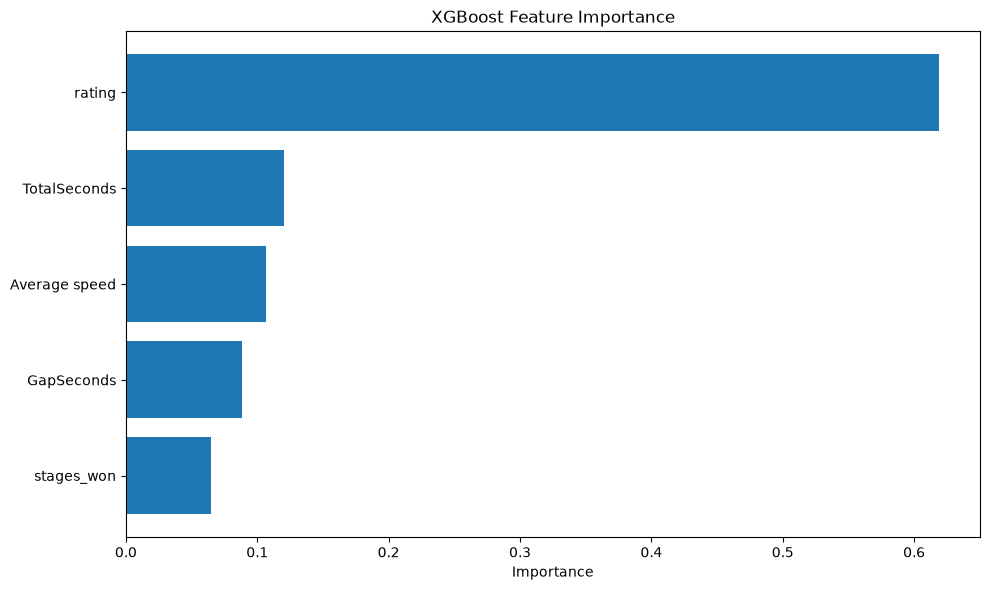

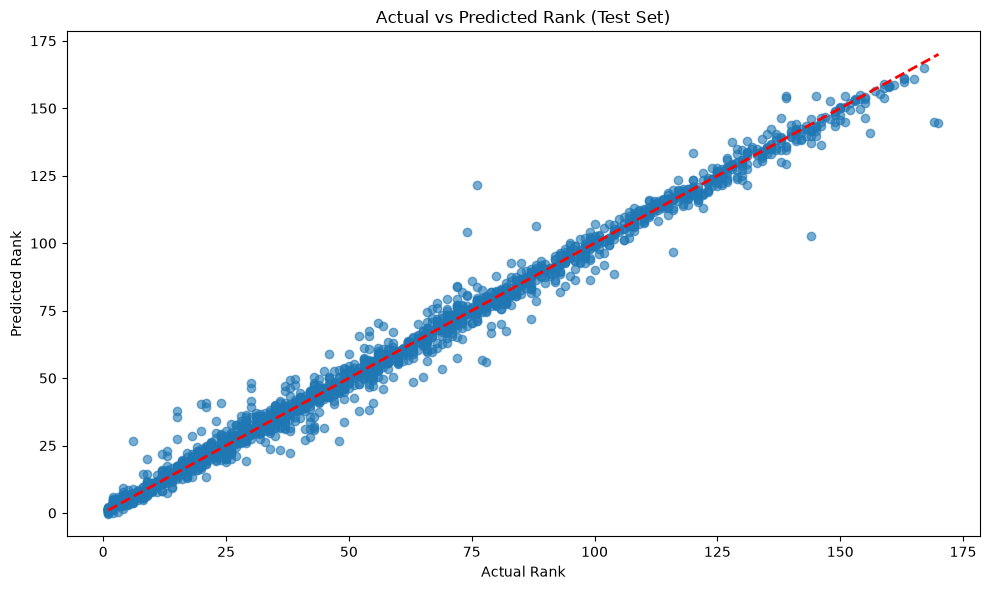

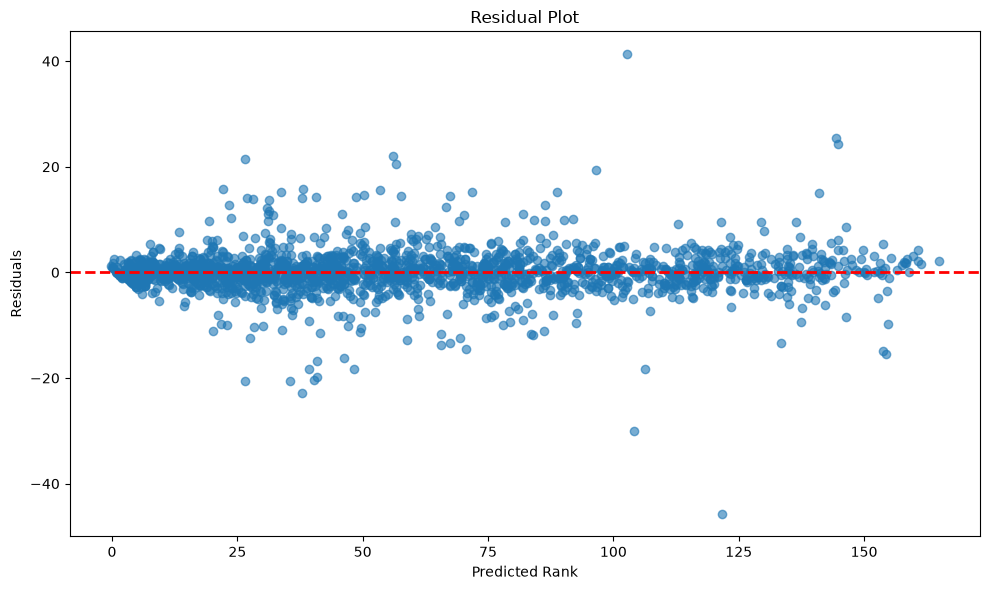

In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data
features = [
    "TotalSeconds",
    "GapSeconds",
    "Average speed",  # You'll need to calculate this if not in data
    "stages_won",
    "rating"
]

# Calculate average speed if not already in data
if "Average speed" not in filtered_riders.columns:
    filtered_riders["Average speed"] = filtered_riders["Distance (km)"] / (filtered_riders["TotalSeconds"] / 3600)

# Prepare X and y
X = filtered_riders[features].copy()
y = filtered_riders["Rank"].copy()

# 2. Handle missing values
print("Missing values before handling:")
print(X.isnull().sum())

# Fill missing values (if any)
X["TotalSeconds"] = X["TotalSeconds"].fillna(X["TotalSeconds"].median())
X["GapSeconds"] = X["GapSeconds"].fillna(0)
X["Average speed"] = X["Average speed"].fillna(X["Average speed"].median())
X["stages_won"] = X["stages_won"].fillna(0)
X["rating"] = X["rating"].fillna(X["rating"].median())

# 3. Check for infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)

# 5. Scale features (XGBoost doesn't require scaling but can help with some features)
scaler = RobustScaler()  # More robust to outliers
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train XGBoost model
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=10,
    eval_metric="mae"
)

# Train with validation set
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=50
)

# 7. Make predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# 8. Evaluate model
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Training metrics
print(f"\nTraining Set:")
print(f"MAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"MSE: {mean_squared_error(y_train, y_pred_train):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"R²: {r2_score(y_train, y_pred_train):.4f}")

# Test metrics
print(f"\nTest Set:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_test):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"R²: {r2_score(y_test, y_pred_test):.4f}")

# 9. Feature Importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("FEATURE IMPORTANCE")
print("="*50)
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 10. Cross-validation
# cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error')
# print(f"\nCross-validation MAE: {-cv_scores.mean():.2f} (+/- {cv_scores.std() * 2:.2f})")

# 11. Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rank')
plt.ylabel('Predicted Rank')
plt.title('Actual vs Predicted Rank (Test Set)')
plt.tight_layout()
plt.show()

# 12. Residual Analysis
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Rank')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [76]:

model_preds=model.predict(X_test)
print(f"accuracy score: ",accuracy_score(y_test,model_preds))
print(f"confusion matrix",confusion_matrix(y_test,model_preds))

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [78]:

with open('letour_ranks.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('letour_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('letour_features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("✅ Model saved successfully with pickle!")

✅ Model saved successfully with pickle!


## Now predicting the rank of a rider

In [109]:
import joblib
import math


# Load the model - use a different variable name
model = joblib.load('letour_ranks.pkl')
scaler = joblib.load('letour_scaler.pkl')
feature_names = joblib.load('letour_features.pkl')  # Use this name

def predict_rider_rank(rider_name, year=None):
    """
    Predict a rider's rank
    
    Parameters:
    - rider_name: str (e.g., "Tadej Pogacar")
    - year: int (e.g., 2025) - if None, uses most recent year
    
    Returns:
    - dict with prediction results
    """
    
    # Filter for the rider
    if year is None:
        rider_data = filtered_riders[
            filtered_riders["Rider"].str.contains(rider_name, case=False, na=False)
        ].sort_values("Year", ascending=False)
    else:
        rider_data = filtered_riders[
            (filtered_riders["Rider"].str.contains(rider_name, case=False, na=False)) &
            (filtered_riders["Year"] == year)
        ]
    
    # Check if rider exists
    if rider_data.empty:
        if year:
            return f"❌ Rider '{rider_name}' not found for year {year}"
        else:
            return f"❌ Rider '{rider_name}' not found in dataset"
    
    # Get the first matching row
    rider_row = rider_data.iloc[0]
    
    # Extract features - using feature_names
    feature_values = rider_row[feature_names].values.reshape(1, -1)
    
    # Scale features
    features_scaled = scaler.transform(feature_values)
    
    # Make prediction
    predicted_rank = math.ceil(model.predict(features_scaled)[0])
    
    # Return results - FIXED: using feature_names
    return {
        'rider': rider_row["Rider"],
        'year': rider_row["Year"],
        'actual_rank': rider_row["Rank"] if "Rank" in rider_row else "Unknown",
        'predicted_rank': round(predicted_rank, 2),
        'features_used': dict(zip(feature_names, rider_row[feature_names].values))
    }

# Test it
result = predict_rider_rank("EDWARD THEUNS", year=2025)
print(f"🏆 {result['rider']} ({result['year']})")
print(f"   Predicted Rank: {result['predicted_rank']}")
print(f"   Actual Rank: {result['actual_rank']}")
print(f"   Features: {result['features_used']}")

🏆 EDWARD THEUNS (2025)
   Predicted Rank: 159
   Actual Rank: 159
   Features: {'TotalSeconds': np.int64(294717), 'GapSeconds': np.int64(21085), 'Average speed': np.float64(40.59080405948758), 'stages_won': np.int64(0), 'rating': np.float64(0.44)}


/Users/kayidax/Documents/Codes/projects/SideHustle/Atp-tour/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
